
<h3 align="center">SA4110 MACHINE LEARNING APPLICATION DEVELOPMENT</h3>
<h4 align="center">CA - TEAM PROJECT - IMAGE CLASSIFIER</h4>
<hr>

<div class="alert alert-block alert-info">
<b><u>Tasks:</u></b> 
<ol>
<li>Create an Image Classifier (CNN model) to classify images of fruits correctly.</li>
<li>A Fruits Dataset is provided that consists of these 3 Classes: -</li>
    <ul>
    <li>Apple</li>
    <li>Banana</li>
    <li>Orange</li>
    </ul>
<li>Use the Images in train.zip and test.zip to Train and Test your Image Classifier.</li>
<li>Document your experiments and results in improving your model’s accuracy.</li>
<li>The Following Activities can Improve your Model’s Accuracy: -</li>
    <ul>
    <li>Balance out the Number of Samples in Each Class</li>
    <li>Correct any mis-labelling in any of the 3 Classes</li>
    <li>Image Augmentation to Generate more Data </li>
    </ul>
<li>Use Matplotlib to Generate any Plots that can Help the Reader understand your Work Better.</li>
</ol></div>



In [57]:
### Step 1: Import the Necessary Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics

import os
os.environ["KERAS_BACKEND"] = "torch"

import torch
import keras

from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from pathlib import Path
from PIL import Image
from IPython.display import display, HTML

In [55]:
### Step 2.1: Load the Training Datasets

# Define the Path Directory to 'train' directory
img_train_dir = Path.cwd().parents[1] / "train"

""" Generate a Classification Labels associated with the Respective Fruit Classes based on FileName """
# Initialize the Required Parameters for the Classification Label
img_T_fileNames = []
img_T_classLabel = []

for img_path in img_train_dir.glob("*.jpg"):
    try:
        img_T_fileNames.append(img_path.name)
        img_T_classLabel.append(img_path.name.strip().split('_')[0])
    except Exception as e:
        print(f"Unable to Read {img_path.name}: {e}")

class_train_df = pd.DataFrame({
    'fileName' : img_T_fileNames,
    'classLabel' : img_T_classLabel
})

display(HTML("<h3>Display (10) Random Sample of the Class Label DataFrame:</h3>"))
display(class_train_df.sample(10)
        .style
        .highlight_null(color='lightcoral')
        .set_properties(**{'color':'white'})
        .set_table_styles([
            {'selector':'tr:nth-child(even)', 'props': [('background-color', '#708090')]},
            {'selector':'th', 'props':[('text-align', 'center')]},
            {'selector':'tr:nth', 'props':[('text-align', 'center')]}
        ]))

print("-" * 50)
for i, label in enumerate(class_train_df['classLabel'].unique(), start = 1):
    print(f"Class Label {i}: {label}")
print("-" * 50)

# Calculting the Images Median Width and Height to Determine the Target Size
img_T_widths = []
img_T_heights = []

for img_path in img_train_dir.rglob("*.jpg"):
    try:
        with Image.open(img_path) as img:
            img_T_widths.append(img.size[0])
            img_T_heights.append(img.size[1])
    except Exception as e:
        print(f"Unable to Read {img_path.name}: {e}")

if img_T_widths and img_T_heights:
    img_T_widths_median = statistics.median(img_T_widths)
    img_T_heights_median = statistics.median(img_T_heights)

    print(f"Total No. of Images Evaluated: {len(img_T_widths)}")
    print(f"Image Median Widths: {img_T_widths_median}")
    print(f"Image Median Heights: {img_T_heights_median}")
else:
    print(f"No .jpg Images found in the Specified Directory.")

,fileName,classLabel
148,orange_1.jpg,orange
150,orange_11.jpg,orange
126,banana_59.jpg,banana
95,banana_30.jpg,banana
76,banana_10.jpg,banana
194,orange_53.jpg,orange
217,orange_76.jpg,orange
171,orange_30.jpg,orange
128,banana_60.jpg,banana
138,banana_7.jpg,banana


--------------------------------------------------
Class Label 1: apple
Class Label 2: banana
Class Label 3: orange
--------------------------------------------------
Total No. of Images Evaluated: 220
Image Median Widths: 640.0
Image Median Heights: 481.5


In [56]:
### Step 2.2: Load the Testing Datasets

# Define the Path Directory to 'test' directory
img_test_dir = Path.cwd().parents[1] / "test"

""" Generate a Classification Labels associated with the Respective Fruit Classes based on FileName """
# Initialize the Required Parameters for the Classification Label
img_t_fileNames = []
img_t_classLabel = []

for img_path in img_test_dir.glob("*.jpg"):
    try:
        img_t_fileNames.append(img_path.name)
        img_t_classLabel.append(img_path.name.strip().split('_')[0])
    except Exception as e:
        print(f"Unable to Read {img_path.name}: {e}")

class_test_df = pd.DataFrame({
    'fileName' : img_t_fileNames,
    'classLabel' : img_t_classLabel
})

display(HTML("<h3>Display (10) Random Sample of the Class Label DataFrame:</h3>"))
display(class_test_df.sample(10)
        .style
        .highlight_null(color='lightcoral')
        .set_properties(**{'color':'white'})
        .set_table_styles([
            {'selector':'tr:nth-child(even)', 'props': [('background-color', '#708090')]},
            {'selector':'th', 'props':[('text-align', 'center')]},
            {'selector':'tr:nth', 'props':[('text-align', 'center')]}
        ]))

print("-" * 50)
for i, label in enumerate(class_test_df['classLabel'].unique(), start = 1):
    print(f"Class Label {i}: {label}")
print("-" * 50)

# Calculting the Images Median Width and Height to Determine the Target Size
img_t_widths = []
img_t_heights = []

for img_path in img_test_dir.rglob("*.jpg"):
    try:
        with Image.open(img_path) as img:
            img_t_widths.append(img.size[0])
            img_t_heights.append(img.size[1])
    except Exception as e:
        print(f"Unable to Read {img_path.name}: {e}")

if img_t_widths and img_t_heights:
    img_t_widths_median = statistics.median(img_t_widths)
    img_t_heights_median = statistics.median(img_t_heights)

    print(f"Total No. of Images Evaluated: {len(img_t_widths)}")
    print(f"Image Median Widths: {img_t_widths_median}")
    print(f"Image Median Heights: {img_t_heights_median}")
else:
    print(f"No .jpg Images found in the Specified Directory.")

,fileName,classLabel
25,banana_83.jpg,banana
6,apple_83.jpg,apple
47,orange_87.jpg,orange
37,orange_77.jpg,orange
0,apple_77.jpg,apple
27,banana_85.jpg,banana
38,orange_78.jpg,orange
30,banana_88.jpg,banana
48,orange_89.jpg,orange
7,apple_84.jpg,apple


--------------------------------------------------
Class Label 1: apple
Class Label 2: banana
Class Label 3: orange
--------------------------------------------------
Total No. of Images Evaluated: 55
Image Median Widths: 650
Image Median Heights: 500


In [74]:
### Step 3: Define a New Class: FruitLabeller

class FruitLabeller(Dataset):
    def __init__(self, class_dataframe, img_directory, transforms = None):
        self.dataframe = class_dataframe
        self.directory = img_directory
        self.transforms = transforms

        unique_labels = sorted(class_dataframe['classLabel'].unique())
        self.label_map = {label: idx for idx, label in enumerate(unique_labels)}
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx]['fileName']
        img_path = self.directory / img_name
        image = Image.open(img_path).convert("RGB")

        label_str = self.dataframe.iloc[idx]['classLabel']
        label = self.label_map[label_str]

        if self.transforms:
            image = self.transforms(image)
        
        return image, label
    
def display_dataset_shape(df, dataset_name):
    shape_df = df['classLabel'].value_counts().sort_index().reset_index()
    shape_df.columns = ['Class Label', 'Total Image']

    display(HTML(f"<h3>{dataset_name} Dataset Shape:</h3>"))
    display(shape_df.style
            .set_properties(**{'color':'white', 'text-align':'center'})
            .set_table_styles([
            {'selector':'tr:nth-child(even)', 'props': [('background-color', '#708090')]},
            {'selector':'th', 'props':[('text-align', 'center')]},
            ])
            .hide(axis="index")
            )

In [75]:
### Step 3: Loading the Image Data in KERAS

# Setting the Target Size
target_width = int(img_T_widths_median) if int(img_T_widths_median) < 224 else int(224)
target_height = int(img_T_heights_median) if int(img_T_heights_median) < 224 else int(224)

# Splitting the Training Data into 80% Training and 20% Validation
train_df, val_df = train_test_split(
    class_train_df,
    test_size=0.2,
    random_state=42,
    stratify=class_train_df['classLabel']
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

# Define the Resizing and Normalization Pipeline for Both Training and Testing Datasets
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=60),
    transforms.ColorJitter(brightness=0.2),
    transforms.RandomCrop(target_height),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(target_height),
    transforms.ToTensor()
])

# Instantiate the Datasets in KERAS
train_dataset = FruitLabeller(train_df, img_train_dir, train_transforms)
val_dataset = FruitLabeller(val_df, img_train_dir, test_transforms)
test_dataset = FruitLabeller(class_test_df, img_test_dir, test_transforms)

# Create the DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Display the Shape of the Respective Datasets
display_dataset_shape(train_df, "Training (80%)")
display_dataset_shape(val_df, "Validation (20%)")
display_dataset_shape(class_test_df, "Testing")

Class Label,Total Image
apple,60
banana,58
orange,58


Class Label,Total Image
apple,15
banana,15
orange,14


Class Label,Total Image
apple,19
banana,18
orange,18


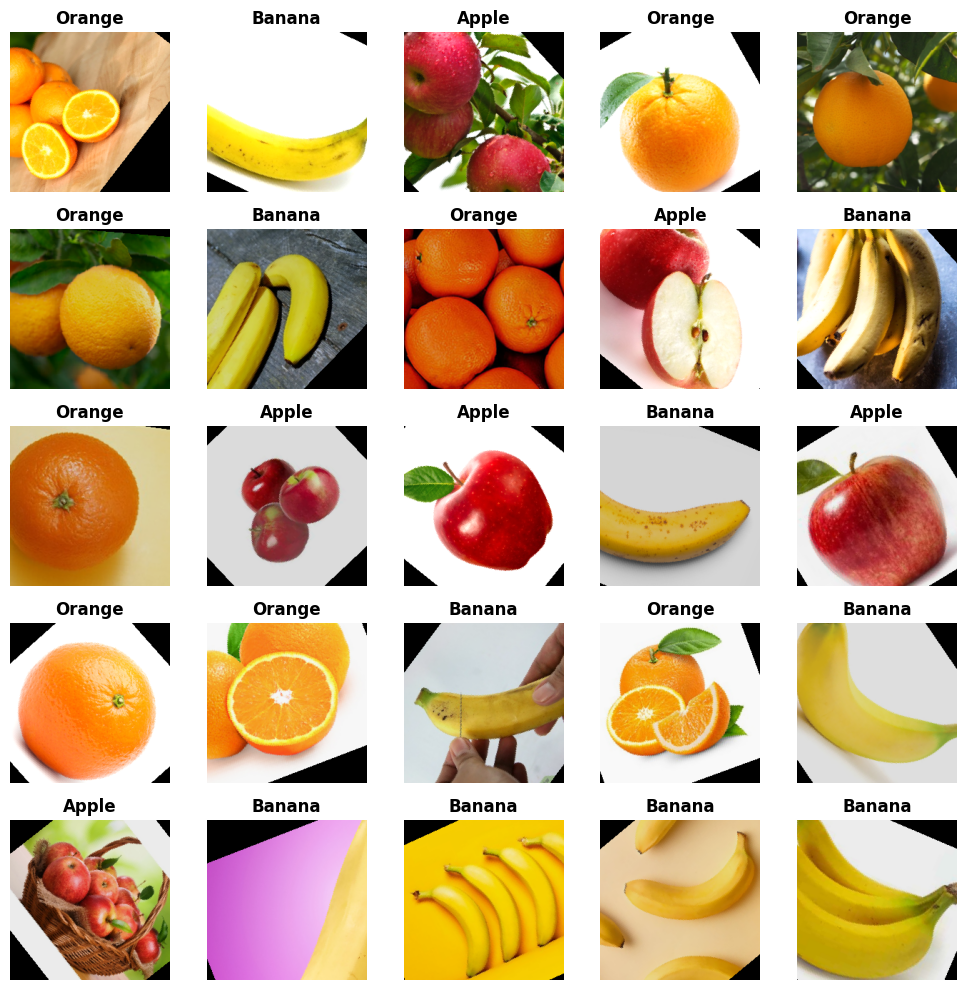

In [71]:
### Step 4: Display Sample Images

images, labels = next(iter(train_loader))
class_names = {0: 'apple', 1: 'banana', 2: 'orange'}

# Set up a 5 x 5 MatPlotLib Grid
fig, axes = plt.subplots(5, 5, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    img = np.transpose(images[i].numpy(), (1, 2, 0))
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    
    # Look up the Integer Label in the Dictionary and Set it as the Title
    label_idx = labels[i].item()
    ax.set_title(class_names[label_idx].capitalize(), fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()